In [33]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [35]:
# Updated file path including the subfolder

# Load the CICMalDroid 2020 dataset

file_path = "/content/drive/MyDrive/Malicious_Mobile_Application_Detection/feature_vectors_syscallsbinders_frequency_5_Cat.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 11598
Number of columns: 471


In [36]:
# Display the first 5 rows
df.head()

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


In [37]:
# Display all column names
print("Total columns:", len(df.columns))

for i, column in enumerate(df.columns):
    print(i, ":", column)

Total columns: 471
0 : ACCESS_PERSONAL_INFO___
1 : ALTER_PHONE_STATE___
2 : ANTI_DEBUG_____
3 : CREATE_FOLDER_____
4 : CREATE_PROCESS`_____
5 : CREATE_THREAD_____
6 : DEVICE_ACCESS_____
7 : EXECUTE_____
8 : FS_ACCESS____
9 : FS_ACCESS()____
10 : FS_ACCESS(CREATE)____
11 : FS_ACCESS(CREATE__APPEND)__
12 : FS_ACCESS(CREATE__READ)__
13 : FS_ACCESS(CREATE__READ__WRITE)
14 : FS_ACCESS(CREATE__WRITE)__
15 : FS_ACCESS(CREATE__WRITE__APPEND)
16 : FS_ACCESS(READ)____
17 : FS_ACCESS(READ__WRITE)__
18 : FS_ACCESS(WRITE)____
19 : FS_PIPE_ACCESS___
20 : FS_PIPE_ACCESS()___
21 : FS_PIPE_ACCESS(READ)___
22 : FS_PIPE_ACCESS(READ__)_
23 : FS_PIPE_ACCESS(READ__WRITE)_
24 : FS_PIPE_ACCESS(WRITE)___
25 : NETWORK_ACCESS____
26 : NETWORK_ACCESS()____
27 : NETWORK_ACCESS(READ)____
28 : NETWORK_ACCESS(READ__WRITE)__
29 : NETWORK_ACCESS(READ__WRITE__)
30 : NETWORK_ACCESS(WRITE)____
31 : NETWORK_ACCESS(WRITE__)__
32 : SMS_SEND____
33 : TERMINATE_PROCESS
34 : TERMINATE_THREAD
35 : __arm_nr_cacheflush
36 : __arm_

In [38]:
# Check the target/class column
print(df["Class"].value_counts())

Class
3    3904
4    2546
2    2100
5    1795
1    1253
Name: count, dtype: int64


In [39]:
# Map the numerical class labels to their actual categories

class_mapping = {
    1: "Adware",
    2: "Banking",
    3: "SMS Malware",
    4: "Riskware",
    5: "Benign"
}

df["Class_Name"] = df["Class"].map(class_mapping)

print(df["Class_Name"].value_counts())

Class_Name
SMS Malware    3904
Riskware       2546
Banking        2100
Benign         1795
Adware         1253
Name: count, dtype: int64


In [40]:
# Check for missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns containing missing values:
Series([], dtype: int64)


In [41]:
# Check for duplicate rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 72


In [42]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Duplicates removed successfully!
New number of rows: 11526
Number of columns: 472


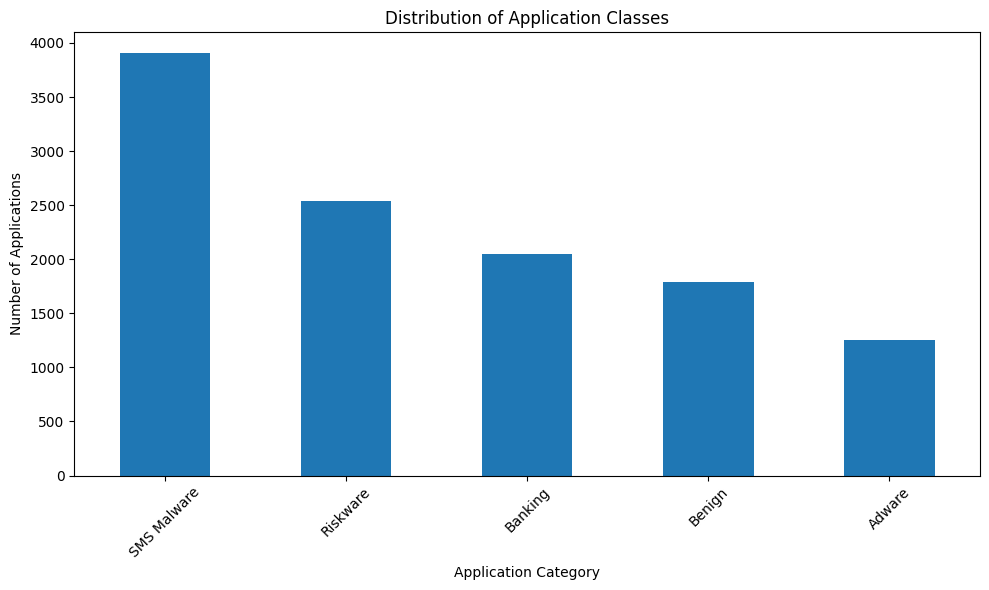

In [43]:
# Visualize the distribution of application classes

plt.figure(figsize=(10, 6))

df["Class_Name"].value_counts().plot(kind="bar")

plt.title("Distribution of Application Classes")
plt.xlabel("Application Category")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [44]:
# Statistical summary of the numerical features

print("Statistical Summary of the Dataset:")
display(df.describe())

Statistical Summary of the Dataset:


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
count,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,...,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,11526.000000,1.152600e+04,11526.000000
mean,57.790908,0.001215,0.044855,5.817283,0.990023,29.929724,29.820319,2.265053,74.103332,6.730175,...,0.093875,2.243797,0.001822,0.000694,6.491845,0.000694,1.658164,1077.795332,1.046051e+03,3.136040
std,445.511577,0.055876,1.107725,10.403308,4.073808,32.205766,268.478022,9.898247,219.691335,20.105990,...,1.813960,15.738632,0.070303,0.029448,164.790110,0.026337,9.957346,6170.094438,1.718172e+04,1.198143
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,10.000000,2.000000,0.000000,8.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.000000,1.200000e+01,2.000000
50%,2.000000,0.000000,0.000000,3.000000,0.000000,17.000000,3.000000,0.000000,21.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,257.000000,4.400000e+01,3.000000
75%,8.000000,0.000000,0.000000,6.000000,0.000000,39.000000,22.000000,0.000000,53.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1152.000000,1.450000e+02,4.000000
max,7647.000000,5.000000,91.000000,700.000000,140.000000,1332.000000,26631.000000,399.000000,8380.000000,1192.000000,...,113.000000,117.000000,6.000000,2.000000,17431.000000,1.000000,1042.000000,490069.000000,1.301356e+06,5.000000


In [45]:
# Find the features with the highest standard deviation

# Exclude the target columns
feature_columns = df.drop(columns=["Class", "Class_Name"])

std_values = feature_columns.std().sort_values(ascending=False)

print("Top 20 features with the highest standard deviation:")
display(std_values.head(20))

Top 20 features with the highest standard deviation:


,0
clock_gettime,47114.420815
sched_yield,43756.444436
gettimeofday,30116.926480
read,17789.451051
writev,17181.715184
futex,14046.289762
ioctl,13711.959934
epoll_wait,9852.912525
getuid32,9256.006010
getpid,8622.439754


In [51]:
from sklearn.feature_selection import VarianceThreshold

# 1. Automatically grab the exact target/class column name (last column)
target_col = df.columns[-1]

print(f"Target/Class column detected as: '{target_col}'")

# 2. Separate input features (X) and target class labels (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. Select only numeric features for variance calculations
X_numeric = X.select_dtypes(include=['number'])

# 4. Filter out constant and low-variance features (variance < 0.01)
selector = VarianceThreshold(threshold=0.01)
X_selected_array = selector.fit_transform(X_numeric)

# 5. Store retained feature names in a clean DataFrame
selected_features = X_numeric.columns[selector.get_support()]
X_filtered = pd.DataFrame(X_selected_array, columns=selected_features)

print(f"Original Feature Count: {X.shape[1]}")
print(f"Features Retained after Variance Filtering: {X_filtered.shape[1]}")

Target/Class column detected as: 'Class_Name'
Original Feature Count: 471
Features Retained after Variance Filtering: 317


In [52]:
# Train-Test Split & Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encode Target Labels if they are text categories (e.g., 'Benign', 'Adware' -> 0, 1, 2...)
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
else:
    y_encoded = y

# 2. Train-Test Split (80% Train, 20% Test) with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape:  {X_test_scaled.shape}")

Training set shape: (9220, 317)
Testing set shape:  (2306, 317)


In [53]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest Classifier on 9,220 samples...")
rf_model.fit(X_train_scaled, y_train)
print("Model training complete!")

Training Random Forest Classifier on 9,220 samples...
Model training complete!


Model Accuracy: 98.22%

--- Classification Report ---
              precision    recall  f1-score   support

      Adware       0.98      0.98      0.98       251
     Banking       0.99      0.97      0.98       409
      Benign       0.96      0.97      0.97       358
    Riskware       0.97      0.98      0.97       507
 SMS Malware       0.99      1.00      1.00       781

    accuracy                           0.98      2306
   macro avg       0.98      0.98      0.98      2306
weighted avg       0.98      0.98      0.98      2306



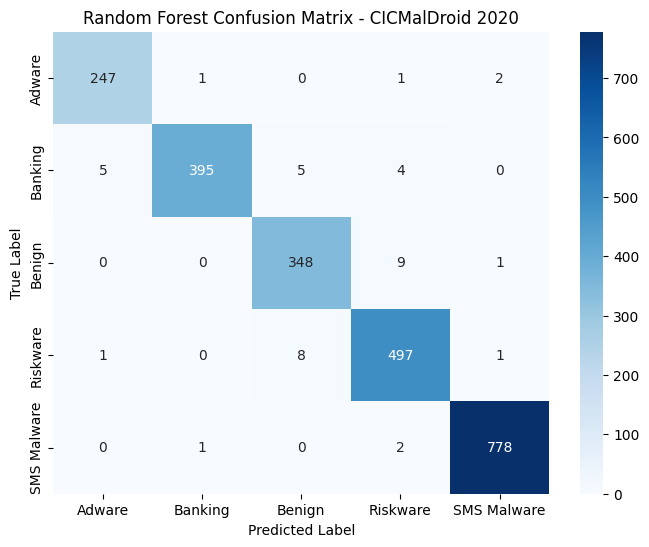

In [54]:
# Evaluate Model Performance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Generate predictions on the 2,306 test samples
y_pred = rf_model.predict(X_test_scaled)

# 2. Overall Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc * 100:.2f}%\n")

# 3. Detailed Metrics (Precision, Recall, F1-Score)
print("--- Classification Report ---")
if 'label_encoder' in locals():
    target_names = [str(cls) for cls in label_encoder.classes_]
    print(classification_report(y_test, y_pred, target_names=target_names))
else:
    print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names if 'label_encoder' in locals() else 'auto',
            yticklabels=target_names if 'label_encoder' in locals() else 'auto')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix - CICMalDroid 2020')
plt.show()

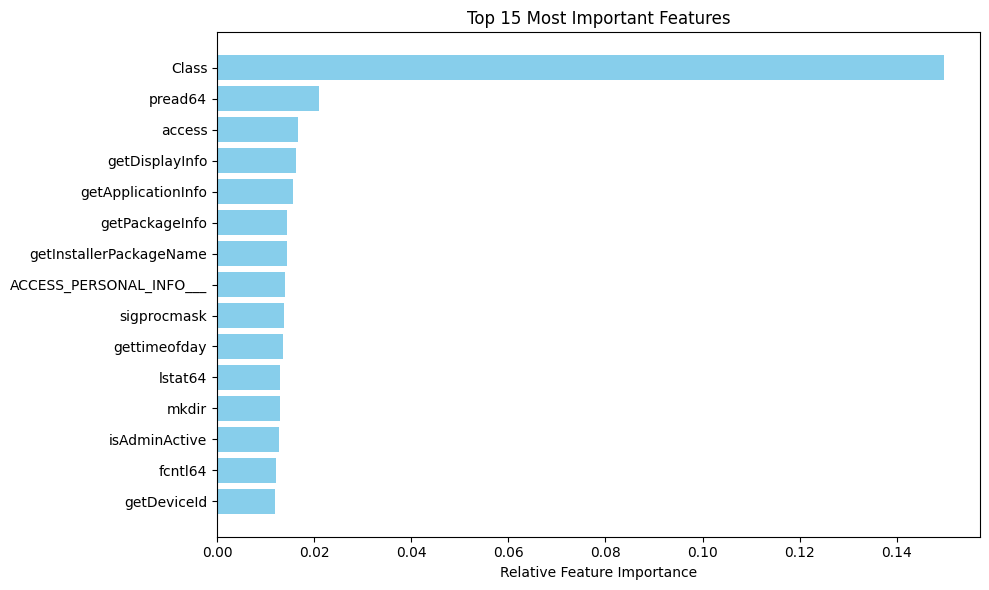

In [55]:
# Extract Top Feature Importances
import numpy as np

# Extract feature importances
importances = rf_model.feature_importances_
top_indices = np.argsort(importances)[::-1][:15]

# Plot top features
plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[top_indices][::-1], align="center", color="skyblue")
plt.yticks(range(15), [X_filtered.columns[i] for i in top_indices][::-1])
plt.xlabel("Relative Feature Importance")
plt.title("Top 15 Most Important Features")
plt.tight_layout()
plt.show()

In [56]:
# Save the Model and Scaler to Google Drive
import joblib
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define export paths
model_path = '/content/drive/MyDrive/malware_rf_model.pkl'
scaler_path = '/content/drive/MyDrive/malware_scaler.pkl'
encoder_path = '/content/drive/MyDrive/malware_label_encoder.pkl'

# 3. Save artifacts
joblib.dump(rf_model, model_path)
joblib.dump(scaler, scaler_path)

if 'label_encoder' in locals():
    joblib.dump(label_encoder, encoder_path)

print("Model, Scaler, and Label Encoder saved successfully to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model, Scaler, and Label Encoder saved successfully to Google Drive!


In [6]:
import json
from google.colab import files

sample_payload = {
    "sample_id": "CIC_MALDROID_SAMPLE_0482",
    "predicted_label": "Banking Malware",
    "top_contributing_features": [
        "android.permission.READ_SMS",
        "android.permission.SEND_SMS",
        "android.permission.RECEIVE_SMS",
        "android.permission.SYSTEM_ALERT_WINDOW",
        "Ljava/lang/reflect/Method;->invoke",
        "android.telephony.TelephonyManager;->getDeviceId",
        "android.content.Context;->registerReceiver"
    ]
}

with open("sample_prediction.json", "w") as f:
    json.dump(sample_payload, f, indent=4)

files.download("sample_prediction.json")
print("sample_prediction.json created and downloading!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

sample_prediction.json created and downloading!
